# Algorithm Performance Measurement and Benchmarking Tool
DAA Lab 2 (ENCA351) - this notebook runs the whole project step by step.

## 1. Import our modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from search_analysis import linear_search, binary_search, generate_dataset
from code_benchmark import single_loop, nested_loop, factorial_recursive, factorial_iterative
from benchmark_engine import BenchmarkEngine, run_all_benchmarks
from visualization import compare_chart, make_all_charts, complexity_table
%matplotlib inline

## 2. Search algorithms (Task 2)
We make a sorted dataset and search for a key that exists and one that does not.

In [2]:
data = generate_dataset(1000, sorted_data=True)
key = data[700]
print("Linear search  (key present):", linear_search(data, key))
print("Binary search  (key present):", binary_search(data, key))
print("Linear search  (key absent) :", linear_search(data, -1))
print("Binary search  (key absent) :", binary_search(data, -1))

Linear search  (key present): (700, 701)
Binary search  (key present): (700, 10)
Linear search  (key absent) : (-1, 1000)
Binary search  (key absent) : (-1, 9)


## 3. Code snippets (Task 3)

In [3]:
engine = BenchmarkEngine()
rows = []
for name, func in [("Single Loop", single_loop), ("Nested Loop", nested_loop),
                   ("Recursive Factorial", factorial_recursive), ("Iterative Factorial", factorial_iterative)]:
    t, mem, ops = engine.measure(func, (500,))
    rows.append({"Snippet": name, "Time (s)": t, "Memory (KB)": mem, "Operations": ops})
pd.DataFrame(rows)

,Snippet,Time (s),Memory (KB),Operations
0,Single Loop,0.000019,0.164062,500
1,Nested Loop,0.011409,1.527344,250000
2,Recursive Factorial,0.000123,8.125000,500
3,Iterative Factorial,0.000063,1.136719,499


## 4. Automated benchmark (Task 4)
Every algorithm is run on all the suggested input sizes. (Nested loop at n = 10,000 takes a few seconds.)

In [4]:
df = run_all_benchmarks()
df.to_csv("benchmark_results.csv", index=False)
df

,algorithm,input_size,time_sec,memory_kb,operations
0,Linear Search,100,3.766400e-06,0.117188,100
1,Linear Search,1000,4.523140e-05,0.207031,1000
2,Linear Search,10000,4.906838e-04,1.611328,10000
3,Linear Search,50000,2.642127e-03,0.207031,50000
4,Binary Search,100,7.574000e-07,0.000000,6
5,Binary Search,1000,1.089600e-06,0.093750,9
6,Binary Search,10000,1.865800e-06,0.125000,13
7,Binary Search,50000,2.283600e-06,0.125000,15
8,Recursive Factorial,100,1.115780e-05,0.195312,100
9,Recursive Factorial,500,1.285434e-04,8.125000,500


## 5. Visualizations (Task 5)

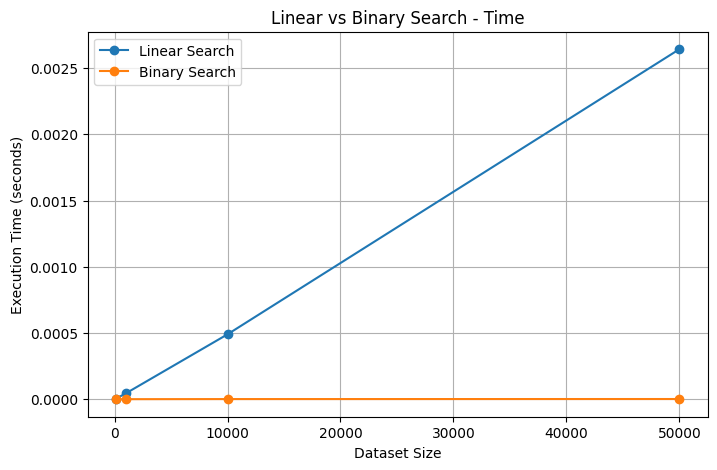

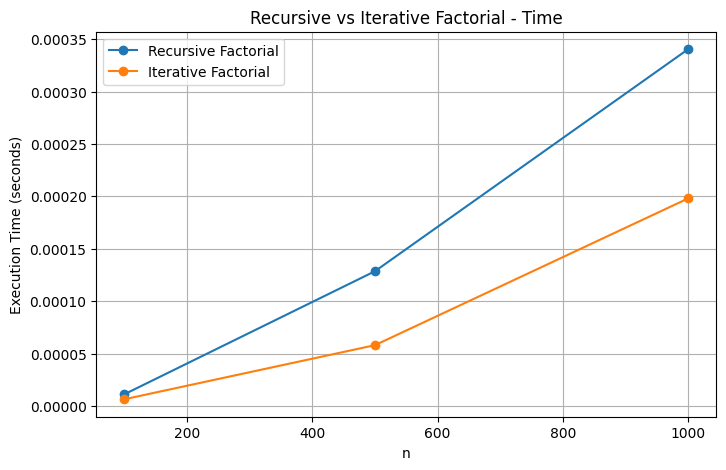

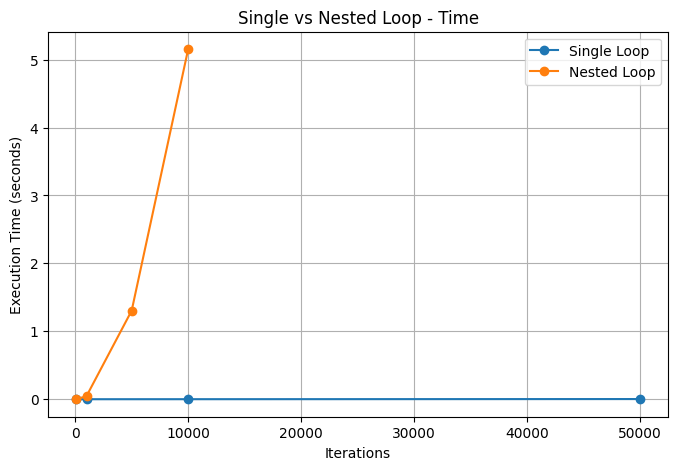

In [5]:
files = make_all_charts(df)
compare_chart(df, ["Linear Search", "Binary Search"], "Dataset Size", "Linear vs Binary Search - Time")
plt.show()
compare_chart(df, ["Recursive Factorial", "Iterative Factorial"], "n", "Recursive vs Iterative Factorial - Time")
plt.show()
compare_chart(df, ["Single Loop", "Nested Loop"], "Iterations", "Single vs Nested Loop - Time")
plt.show()

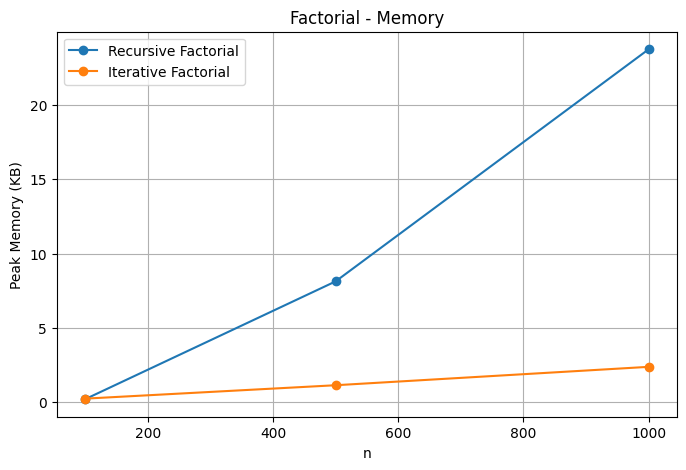

In [6]:
compare_chart(df, ["Recursive Factorial", "Iterative Factorial"], "n", "Factorial - Memory", "memory_kb", "Peak Memory (KB)")
plt.show()

## 6. Complexity analysis (Task 6)
The *growth exponent* is the slope of log(time) vs log(n): about 1 = linear, about 2 = quadratic.

In [7]:
table = complexity_table(df)
table.to_csv("complexity_table.csv", index=False)
table

,Algorithm,Time Complexity,Space Complexity,Largest n,Time at largest n (s),Memory at largest n (KB),Growth exponent,Observed trend
0,Linear Search,O(n),O(1),50000,0.002642,0.21,1.05,Linear growth
1,Binary Search,O(log n),O(1),50000,0.000002,0.12,0.18,Almost constant / logarithmic
2,Recursive Factorial,O(n),O(n),1000,0.000340,23.75,1.49,Linear growth
3,Iterative Factorial,O(n),O(1),1000,0.000198,2.38,1.47,Linear growth
4,Single Loop,O(n),O(1),50000,0.002606,0.17,1.07,Linear growth
5,Nested Loop,O(n²),O(1),10000,5.153218,2.00,2.05,Quadratic growth


## 7. Observations (Task 7)
* **Linear vs Binary search:** linear search time grows in a straight line with n; binary search stays almost flat (only about 15 comparisons for 50,000 items).
* **Single vs Nested loop:** when n grows 10x, the single loop takes about 10x longer but the nested loop takes about 100x longer.
* **Recursive vs Iterative factorial:** both are O(n) in time, but the recursive version uses much more memory (call stack of depth n) while the iterative one uses O(1) extra space.
* **Complexity vs real time:** the growth exponents measured above match the theory (about 1 for O(n), about 2 for O(n^2), close to 0 for O(log n)).